### BreaKHis 400X Dataset
The BreaKHis 400X dataset consists of microscopic images of breast tissue samples, divided into two main classes: benign and malignant. The images are organized into training and test sets, with each set containing separate folders for benign and malignant samples. Each image has a magnification factor of 400X, providing high-resolution details for analysis. This dataset is suitable for developing and evaluating machine learning models for binary classification tasks in histopathological image analysis, specifically to distinguish between benign and malignant breast cancer samples.


In [1]:
# pip install --upgrade scikit-learn

In [2]:
# pip install --upgrade kagglehub

### Importing Libraries
This section imports the necessary libraries for data manipulation, visualization, and building a convolutional neural network model. Key libraries include NumPy for numerical operations, Pandas for data handling, Matplotlib and Seaborn for plotting, and TensorFlow/Keras for deep learning.

In [22]:
# System utilities and warnings
import os  # For interacting with the operating system

# Image Processing
import cv2  # Advanced image processing functions
from PIL import Image  # Basic image manipulation with PIL

# Data Manipulation and Analysis
import numpy as np  # For numerical operations and linear algebra
import pandas as pd  # For handling and manipulating tabular data

# Data Visualization
import matplotlib.pyplot as plt  # Basic plotting for data visualization

# Utility Libraries
import random  # For generating random numbers or selections
from tqdm import tqdm  # Progress bar for long-running loops

# Deep Learning with TensorFlow/Keras
import tensorflow as tf  # Core framework for deep learning tasks
from tensorflow.keras.models import Sequential  # Sequential model structure for neural networks
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator  # Image loading and augmentation
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout,
)  # Layers for building neural network architectures
from tensorflow.keras.optimizers import Adam  # Optimizer for training the model
from tensorflow.keras.utils import to_categorical  # Converts labels to categorical format
from tensorflow.keras.callbacks import ReduceLROnPlateau  # Training callbacks

# Keras Metrics and Additional Tools
from keras.applications import DenseNet169 # Transfer learning models

# Data Splitting and Resampling (Scikit-learn)
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test sets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve  # Classification metrics, confusion matrix and ROC metrics

# Kaggle Dataset Access
import kagglehub  # Direct access to Kaggle datasets

### Downloading the BreaKHis Dataset from Kaggle Hub
This code snippet downloads the latest version of the 'BreaKHis' dataset from Kaggle Hub using the `kagglehub` library. It stores the path to the downloaded dataset files in the variable `path`. After the download is complete, it prints the dataset file path to verify the successful download, allowing users to locate the files for further processing or analysis.


In [4]:
# Download the latest version of the 'BreaKHis' dataset from Kaggle Hub
path = kagglehub.dataset_download("forderation/breakhis-400x")

# Print the dataset file path to verify successful download
print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\forderation\breakhis-400x\versions\1


### Image Path Initialization
This code snippet initializes the paths and labels for the images in the BreaKHis 400X dataset, which is organized into 'train' and 'test' directories, each containing subdirectories for 'benign' and 'malignant' classes. It creates empty lists to store the image paths and corresponding class labels. The code iterates through the directory structure, constructing full image paths and separating them into training and testing datasets, while providing progress feedback using the `tqdm` library for visualization.


In [5]:
# Define the base directory for the BreaKHis 400X dataset images
BASE_DIR = "C:/Users/USER/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1/BreakHis 400x"

In [6]:
# Initialize empty lists for train and test image paths and class labels
image_train_paths = []
class_train_labels = []
image_test_paths = []
class_test_labels = []

# Iterate over 'train' and 'test' folders
for split in ["train", "test"]:
    split_dir = os.path.join(BASE_DIR, split)

    # Iterate over 'benign' and 'malignant' folders
    for class_label in ["benign", "malignant"]:
        class_dir = os.path.join(split_dir, class_label)

        # Iterate over each image file in the class folder
        for filename in tqdm(os.listdir(class_dir), desc=f"Processing {class_label} images in {split}"):
            image_path = os.path.join(class_dir, filename)  # Create full image path

            # Separate train and test data
            if split == "train":
                image_train_paths.append(image_path)  # Store the train image path
                class_train_labels.append(class_label)  # Store the train class label
            elif split == "test":
                image_test_paths.append(image_path)  # Store the test image path
                class_test_labels.append(class_label)  # Store the test class label

Processing malignant images in test: 100%|██████████| 369/369 [00:00<?, ?it/s]


### Creating a DataFrame
This code snippet creates an empty DataFrame using the pandas library and assigns the image paths and corresponding class labels from the previously initialized lists (`image_train_paths` and `class_train_labels`) to the DataFrame. The resulting DataFrame consists of two columns: "image" for the image paths and "class" for the class labels. Finally, it displays the constructed DataFrame.


In [7]:
# Create an empty DataFrame using pandas
data = pd.DataFrame()

# Assign image paths and class labels to the DataFrame
data["image"], data["class"] = image_train_paths, class_train_labels

# Display the resulting DataFrame
data

,image,class
0,C:/Users/USER/.cache/kagglehub/datasets/forder...,benign
1,C:/Users/USER/.cache/kagglehub/datasets/forder...,benign
2,C:/Users/USER/.cache/kagglehub/datasets/forder...,benign
3,C:/Users/USER/.cache/kagglehub/datasets/forder...,benign
4,C:/Users/USER/.cache/kagglehub/datasets/forder...,benign
...,...,...
1143,C:/Users/USER/.cache/kagglehub/datasets/forder...,malignant
1144,C:/Users/USER/.cache/kagglehub/datasets/forder...,malignant
1145,C:/Users/USER/.cache/kagglehub/datasets/forder...,malignant
1146,C:/Users/USER/.cache/kagglehub/datasets/forder...,malignant


### Visualizing Class Distribution
This code snippet retrieves the counts of each class category from the "class" column of the DataFrame. It then creates a bar chart to visualize the distribution of samples between the two classes: "Benign" and "Malignant." The chart is customized with a title and axis labels, providing a clear representation of the class counts. Finally, the chart is displayed using `plt.show()`.


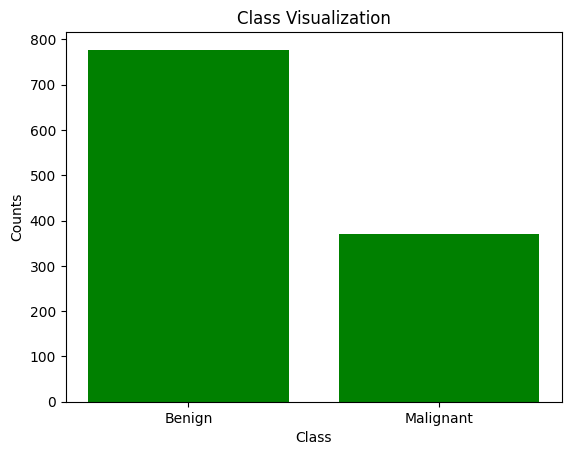

In [8]:
# Get class category counts from the "class" column
x = data["class"].value_counts()

# Create a figure to visualize class class distribution
plt.figure()

# Labels for classs in the chart
class_labels = ["Benign", "Malignant"]

# Create a bar chart to visualize the sample counts for each class
plt.bar(class_labels, x.values, color="green")

plt.title("Class Visualization")  # Set chart title
plt.xlabel("Class")  # Label X-axis
plt.ylabel("Counts")  # Label Y-axis

plt.show()  # Display the chart

### Displaying Sample Images
This code snippet visualizes a grid of sample images from the BreaKHis dataset by creating a 5x5 subplot. It defines a dictionary to map class indices to readable labels ("Benign" and "Malignant"). The code selects the first 25 rows from the DataFrame for visualization and iterates through these rows using `itertuples` to access the image file paths and their corresponding class labels. For each image, it loads the image, converts it to a NumPy array, and displays it in the subplot, setting the title to indicate the class label while turning off the axis labels and ticks for a cleaner presentation.


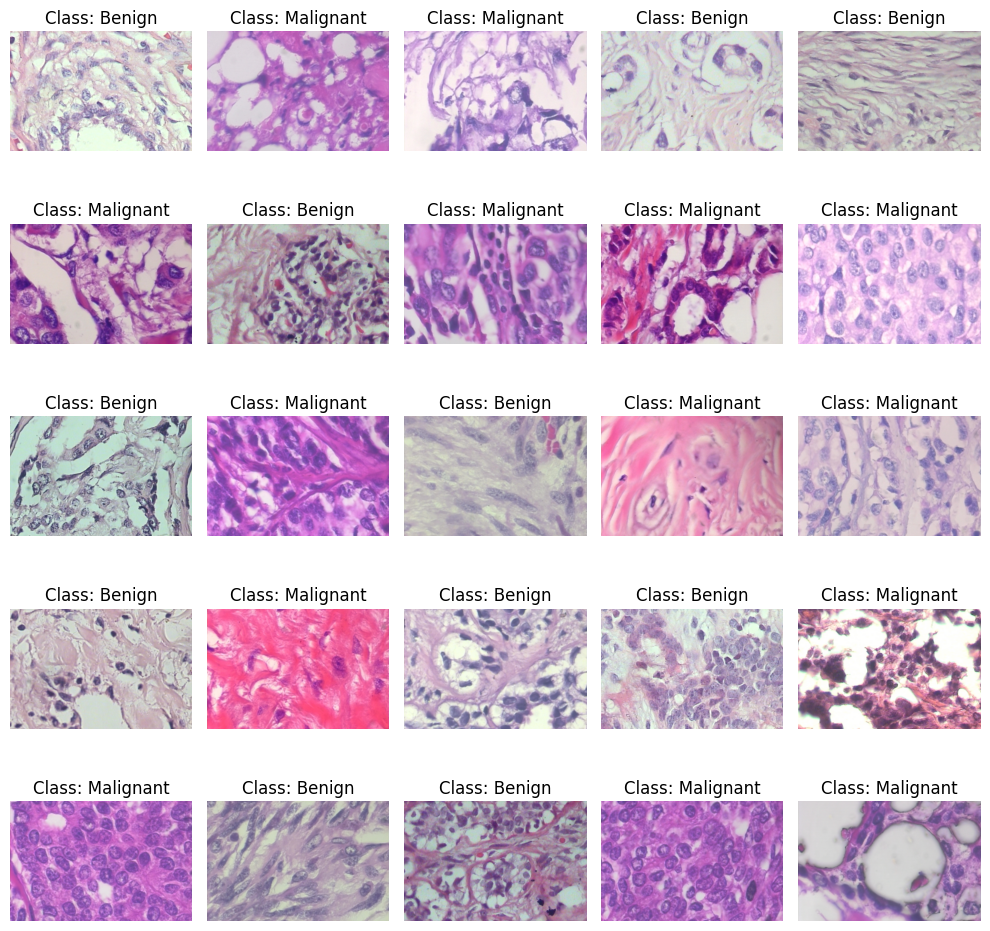

In [9]:
# Dictionary to map class indices to readable labels
class_dict = {0: "Benign", 1: "Malignant"}

# Set figure size to display a grid of images
plt.figure(figsize=(10, 10))

# Randomly select 25 rows from the DataFrame "data" for visualization
files = data.sample(n=25, random_state=42)  # Set random_state for reproducibility

# Reset the index of the sampled DataFrame to ensure proper subplot indexing
files = files.reset_index(drop=True)

# Iterate through selected rows using itertuples to access indices and columns
for index, (file, classes) in enumerate(zip(files["image"], files["class"])):
    plt.subplot(5, 5, index + 1)  # Create a 5x5 subplot grid for each image

    img = load_img(file)  # Load the image
    img = np.array(img)  # Convert the image to a NumPy array

    plt.imshow(img)  # Display the image in the subplot

    # Map string classes to integers
    class_index = 0 if classes.lower() == "benign" else 1

    plt.title(f"Class: {class_dict[class_index]}")  # Set title with corresponding class label
    plt.axis("off")  # Turn off axis labels and ticks

# Display the grid of images
plt.tight_layout()
plt.show()

### Loading and Preprocessing the Dataset
The following code snippet demonstrates how to load and preprocess the BreaKHis dataset. It defines a function, `dataset_loader`, to handle loading image files from a given directory, resizing them to a specified dimension, and applying preprocessing steps such as Gaussian blur and normalization. The dataset is split into four categories: benign training, malignant training, benign test, and malignant test, each of which is processed independently.

In [10]:
# Function to load and preprocess a dataset from a specified directory
def dataset_loader(DIR, RESIZE):
    image_list = []  # List to store preprocessed images

    # Helper function to read an image and convert it to RGB format
    def read(imname):
        return np.asarray(Image.open(imname).convert("RGB"))

    # Iterate through all files in the specified directory
    for IMAGE_NAME in tqdm(os.listdir(DIR)):
        PATH = os.path.join(DIR, IMAGE_NAME)  # Construct the full path to the image
        _, ftype = os.path.splitext(PATH)  # Extract the file type

        # Process only .png files
        if ftype == ".png":
            img = read(PATH)  # Read the image
            img = cv2.resize(img, (RESIZE, RESIZE))  # Resize the image to the specified dimensions

            # Apply Gaussian blur to the image
            img = cv2.GaussianBlur(img, (5, 5), cv2.BORDER_DEFAULT)

            # Normalize the pixel values to the range [-1, 1]
            img = (img / 127.5) - 1.0

            # Append the preprocessed image to the list
            image_list.append(img)

    return image_list  # Return the list of preprocessed images

# Load the benign and malign training images, resize them to 224x224, and preprocess them
benign_train = np.array(dataset_loader(f"{BASE_DIR}/train/benign", 224))
malign_train = np.array(dataset_loader(f"{BASE_DIR}/train/malignant", 224))

# Load the benign and malign test images, resize them to 224x224, and preprocess them
benign_test = np.array(dataset_loader(f"{BASE_DIR}/test/benign", 224))
malign_test = np.array(dataset_loader(f"{BASE_DIR}/test/malignant", 224))

100%|██████████| 369/369 [00:03<00:00, 104.71it/s]


### Preparing the Dataset for Training
This code snippet demonstrates how to prepare the dataset for training and validation by assigning labels, merging datasets, and splitting the data into training and validation sets. The process involves the following steps:

1. Creating Binary Labels:
Assigns `0` for benign samples and `1` for malignant samples, creating separate label arrays for both training and test datasets.
2. Merging Datasets:
Combines benign and malignant images into single datasets (`X_train` and `X_test`) and their corresponding labels into single label arrays (`Y_train` and `Y_test`).
3. One-Hot Encoding Labels:
Converts binary labels into one-hot encoded format to make the labels compatible with a multi-class classification model.
4. Splitting the Data:
Splits the training data (`X_train` and Y_train``) into training and validation subsets using an 80-20 split. The random seed (`random_state=11`) ensures reproducibility of the split.

In [11]:
# Create binary labels for the benign and malignant training datasets
benign_train_label = np.zeros(len(benign_train))  # Label 0 for benign training samples
malign_train_label = np.ones(len(malign_train))  # Label 1 for malignant training samples

# Create binary labels for the benign and malignant test datasets
benign_test_label = np.zeros(len(benign_test))  # Label 0 for benign test samples
malign_test_label = np.ones(len(malign_test))  # Label 1 for malignant test samples

# Combine benign and malignant training and test data into a single dataset
X_train = np.concatenate((benign_train, malign_train), axis=0)
X_test = np.concatenate((benign_test, malign_test), axis=0)

# Combine benign and malignant training and test labels into a single label array
Y_train = np.concatenate((benign_train_label, malign_train_label), axis=0)
Y_test = np.concatenate((benign_test_label, malign_test_label), axis=0)

# Convert binary labels into one-hot encoded format for multi-class classification
Y_train = to_categorical(Y_train, num_classes=2)  # One-hot encode training labels
Y_test = to_categorical(Y_test, num_classes=2)  # One-hot encode test labels

# Split the training dataset into training and validation sets
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=11)

### Data Augmentation for Training
This snippet sets up data augmentation for the training dataset using the `ImageDataGenerator` class from Keras. Data augmentation enhances the dataset by applying random transformations to images, which helps improve the model's ability to generalize.

In [12]:
# Define the batch size for training the model
BATCH_SIZE = 16

# Create an instance of the ImageDataGenerator for data augmentation
train_generator = ImageDataGenerator(
    zoom_range=2,  # Apply random zoom to images within a range
    rotation_range=90,  # Randomly rotate images within a range of 90 degrees
    horizontal_flip=True,  # Randomly flip images horizontally
    vertical_flip=True,  # Randomly flip images vertically
)

### Building a Transfer Learning Model with DenseNet169
This code implements a transfer learning model using the DenseNet169 architecture as the base model. The sequential model is customized for binary classification.

1. DenseNet169 Base Model:
Loads pre-trained weights from ImageNet.
Excludes the top layer for customization (`include_top=False`).
Defines input shape as (`224, 224, 3`) for RGB images.
2. Sequential Model:
Adds the DenseNet169 base model for feature extraction.
Includes layers for classification:
Flatten: Converts the output of the base model into a 1D vector.
Dropout Layers: Adds dropout (30% and 50%) to reduce overfitting.
Dense Layers: Adds a hidden layer with 256 units and ReLU activation, and an output layer with softmax activation for binary classification.
3. Compilation:
Uses `categorical_crossentropy` as the loss function for multi-class classification.
Implements the Adam optimizer with a learning rate of `0.0001` and decay.
Tracks metrics:
ROC AUC: Evaluates the model's ability to distinguish between classes.
Accuracy: Tracks the percentage of correct predictions.
4. Model Summary:
Displays the architecture, including the number of layers and trainable parameters, using `model.summary()`.

In [13]:
# Load the DenseNet169 pre-trained model as the base for transfer learning
base_model = DenseNet169(
    weights='imagenet',  # Load weights pre-trained on the ImageNet dataset
    include_top=False,  # Exclude the fully connected top layer to customize the architecture
    input_shape=(224, 224, 3),  # Set input dimensions (224x224 RGB images)
    classes=2  # Define the number of output classes (binary classification)
)

# Build the sequential model
model = Sequential([
    base_model,  # Add the DenseNet169 base model
    Flatten(),  # Flatten the output of the base model into a 1D vector
    Dropout(0.3),  # Add a 30% dropout layer to reduce overfitting
    Dense(256, activation='relu'),  # Add a dense layer with 256 units and ReLU activation
    Dropout(0.5),  # Add a 50% dropout layer for additional regularization
    Dense(2, activation='softmax')  # Add the output layer with softmax activation for binary classification
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',  # Use categorical crossentropy loss for classification
    optimizer=Adam(learning_rate=0.0001, decay=0.0001 / 50),  # Use the Adam optimizer with a learning rate of 0.0001 and decay
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),  # Track the ROC AUC metric
        "accuracy"  # Track accuracy as an additional evaluation metric
    ]
)

# Print a summary of the model architecture
model.summary()

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 81536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 81536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,873,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,516,866 (127.86 MB)

 Trainable params: 33,358,466 (127.25 MB)

 Non-trainable params: 158,400 (618.75 KB)

### Training the Model with Learning Rate Adjustment
This code snippet trains the binary classification model while dynamically adjusting the learning rate during training to improve convergence and prevent overfitting. The process involves:

1. Learning Rate Reducer Callback:
The `ReduceLROnPlateau` callback monitors the validation accuracy (`val_acc`).
If the validation accuracy does not improve for 5 consecutive epochs (`patience=5`), the learning rate is reduced by a factor of `0.2`.
The minimum learning rate is capped at `0.0000001` to prevent overly small adjustments.
A verbosity level of `1` ensures that messages are printed when the learning rate changes.
2. Model Training:
The model is trained for **50 epochs** with a batch size defined by `BATCH_SIZE`.
The `fit` function uses `x_train` and `y_train` as training data and evaluates performance on the validation dataset (`x_test`, `y_test`) at the end of each epoch.
The `callbacks` parameter integrates the learning rate reducer, ensuring the learning rate is dynamically adjusted during training.
3. History Object:
The training process returns a `history` object containing information about the loss and metrics for each epoch, which can be used for further analysis or visualization.

In [14]:
# Define a learning rate reducer callback to dynamically adjust the learning rate
learn_control = ReduceLROnPlateau(
    monitor='val_acc',  # Monitor the validation accuracy during training
    patience=5,  # Wait for 5 epochs without improvement before reducing the learning rate
    verbose=1,  # Print messages when the learning rate is reduced
    factor=0.2,  # Reduce the learning rate by a factor of 0.2 (i.e., new_lr = current_lr * 0.2)
    min_lr=0.0000001  # Set the minimum learning rate to avoid excessively small values
)

# Train the model using the training data, while monitoring performance on the validation set
history = model.fit(
    train_generator.flow(x_train, y_train, batch_size=BATCH_SIZE),  # Training features, labels and batch size
    epochs=50,  # Train for 50 epochs
    validation_data=(x_test, y_test),  # Evaluate performance on the validation dataset
    callbacks=learn_control   # Use the learning rate reducer as a callback
)

Epoch 1/50


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


58/58 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.5862 - loss: 2.0859 - roc_auc: 0.6146 - val_accuracy: 0.7522 - val_loss: 0.5367 - val_roc_auc: 0.8353 - learning_rate: 1.0000e-04
Epoch 2/50


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,roc_auc,val_accuracy,val_loss,val_roc_auc,learning_rate.
  callback.on_epoch_end(epoch, logs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7522 - loss: 0.5511 - roc_auc: 0.8263 - val_accuracy: 0.7957 - val_loss: 0.4864 - val_roc_auc: 0.8628 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7875 - loss: 0.4847 - roc_auc: 0.8577 - val_accuracy: 0.7957 - val_loss: 0.4090 - val_roc_auc: 0.8967 - learning_rate: 1.0000e-04
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8062 - loss: 0.3998 - roc_auc: 0.9009 - val_accuracy: 0.8783 - val_loss: 0.3539 - val_roc_auc: 0.9249 - learning_rate: 1.0000e-04
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8676 - loss: 0.3679 - roc_auc: 0.9228 - val_accuracy: 0.8870 - val_loss: 0.2980 - val_roc_auc: 0.9439 - learning_rate: 1.0000e-04
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8602 - loss: 0.3392 - roc_auc: 0.9292 - val_accuracy: 0.9087 - val_loss: 0.2245 - val_roc_auc: 0.9700 - learning_rate: 1.0000e-04
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━

### Visualizing Training History
This code converts the training history into a Pandas DataFrame to analyze metrics and plots:

1. Metrics DataFrame: Converts `history.history` into `densenet_history_df` for structured analysis.
2. Accuracy Plot: Displays training (`accuracy`) and validation accuracy (`val_accuracy`) over epochs.
3. Loss Plot: Shows training (`loss`) and validation loss (`val_loss`) trends.

<Axes: >

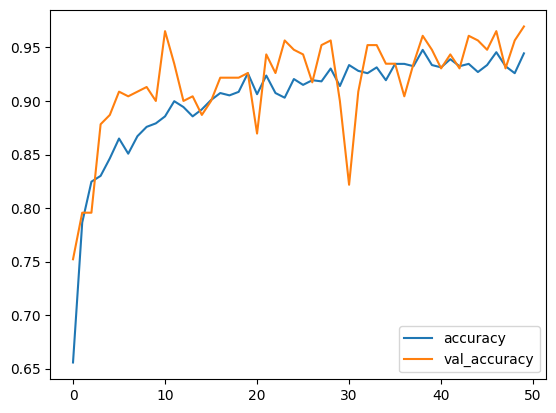

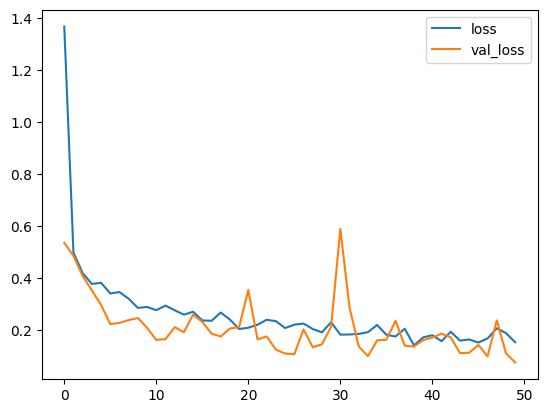

In [15]:
# Convert the training history into a Pandas DataFrame for analysis and visualization
densenet_history_df = pd.DataFrame(history.history)

# Display the DataFrame containing metrics and loss values for each epoch
densenet_history_df

# Plot the training and validation accuracy over epochs
densenet_history_df[['accuracy', 'val_accuracy']].plot()  # 'accuracy' for training, 'val_accuracy' for validation

# Reassign the DataFrame for further use (optional)
densenet_history_df = pd.DataFrame(history.history)

# Plot the training and validation loss over epochs
densenet_history_df[['loss', 'val_loss']].plot()  # 'loss' for training, 'val_loss' for validation

### Model Evaluation Metrics
This code evaluates the performance of a trained machine learning model on a test dataset using standard classification metrics:

1. Prediction: The trained model predicts the labels for the test data (`x_test`) and stores them in `y_pred`.
2. Accuracy: Computes the proportion of correctly classified samples using `accuracy_score`.
3. Precision: Calculates the ratio of true positive predictions to all positive predictions using `precision_score`.
4. Recall: Measures the ratio of true positive predictions to all actual positive cases using `recall_score`.
5. F1 Score: Combines precision and recall into a harmonic mean, offering a balanced evaluation using `f1_score`.

In [16]:
# Use the trained model to predict labels for the test dataset
y_pred = model.predict(x_test)

# Print a header for the evaluation metrics
print("Model Evaluation Metrics")

# Calculate and print the accuracy of the model's predictions
print(f"Accuracy: {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))}")

# Calculate and print the precision of the model's predictions
print(f"Precision: {precision_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))}")

# Calculate and print the recall of the model's predictions
print(f"Recall: {recall_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))}")

# Calculate and print the F1 score of the model's predictions
print(f"F1 Score: {f1_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step
Model Evaluation Metrics
Accuracy: 0.9695652173913043
Precision: 0.9797297297297297
Recall: 0.9731543624161074
F1 Score: 0.9764309764309764


### Visualizing the Confusion Matrix
This code plots a confusion matrix to visualize the model's performance in classifying the test dataset. We generate the confusion matrix using the `confusion_matrix` function by comparing the expected and predicted labels. The confusion matrix is then displayed as a matrix plot using Matplotlib. We add titles and labels for clarity, indicating the true and predicted class labels. This visualization provides a comprehensive view of the classification performance, allowing us to see where the model is correctly predicting classes and where it is making errors, thus highlighting areas for potential improvement.

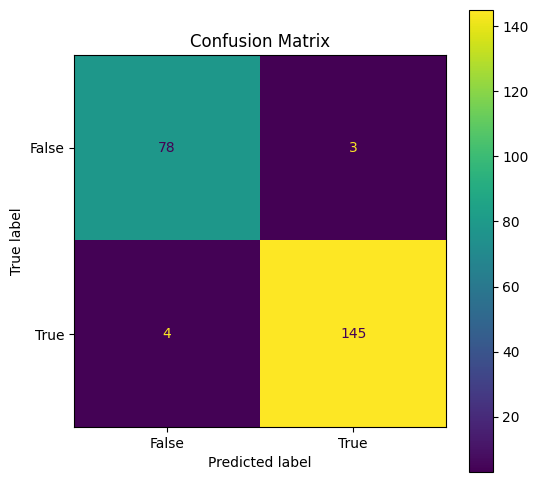

In [23]:
# Convert predicted probabilities to discrete class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Generate the confusion matrix from expected and predicted labels
cm = confusion_matrix(y_test_classes, y_pred_classes)  # Compute confusion matrix

# Define class names for better understanding
class_names = ['False', 'True']  # Modify this based on your specific classes

# Create a plot for the confusion matrix with additional annotations
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix with labels and color bar
disp.plot(cmap='viridis', ax=ax, colorbar=True)

# Add more clarity to the plot
plt.title('Confusion Matrix')
plt.show()

### Visualizing the ROC Curves for Multiclass Classification
This code plots the ROC (Receiver Operating Characteristic) curves for each class in a multiclass classification problem. The ROC curve plots the true positive rate (TPR) against the false positive rate (FPR), providing a graphical representation of the model's performance at different thresholds. This visualization allows us to assess the trade-off between sensitivity and specificity for each class.

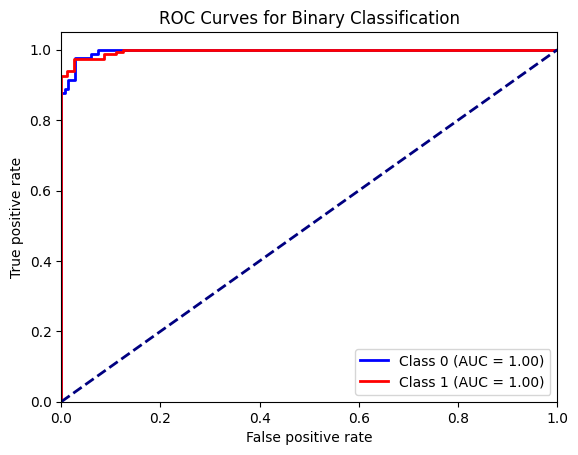

In [24]:
# Number of classes in the classification problem
n_classes = 2

# Dictionaries to hold false positive rates, true positive rates, and ROC AUC values
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

# Calculate FPR, TPR, and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])  # Compute ROC curve
    roc_auc[i] = roc_auc_score(y_test[:, i], y_pred[:, i])  # Compute AUC

# Create a new figure for the ROC curves
plt.figure()
colors = ["blue", "red"]  # Colors for each class

# Plot the ROC curve for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.2f})")  # Plot ROC

# Plot a diagonal line for reference
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])  # Set x-axis limits
plt.ylim([0.0, 1.05])  # Set y-axis limits

# Add labels and title
plt.xlabel("False positive rate")  # X-axis label
plt.ylabel("True positive rate")  # Y-axis label
plt.title("ROC Curves for Binary Classification")  # Title of the plot

# Show legend and display the plot
plt.legend(loc="lower right")
plt.show()  # Display the ROC curves

### Visualizing Predictions
This code randomly selects 20 images from the test dataset and visualizes their true and predicted labels:

1. Random Selection: Picks 20 random indices from the test dataset (`x_test`) using `random.sample`.
2. Prediction: The model predicts the labels for the test dataset and stores them in `y_pred`.
3. Class Labels: Labels the predictions as `Benign` or `Malignant` using the `class_names` list.
4. Image Visualization: Displays the randomly selected test images with their true and predicted labels:
    - Subplots: Organizes the 20 images in a 5x4 grid.
    - Titles: Each subplot shows the true class and predicted class.
    - Layout: Adjusts the layout with `tight_layout` for better spacing.
5. Figure Display: Renders the grid of images using `plt.show()`.

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2705882352941177..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2941176470588235..0.7725490196078431].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6705882352941177..0.9921568627450981].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392156862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8745098039215686..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8352941176470589..0.9372549019607843].
Clipping input data to the valid range for imshow with RGB data ([0

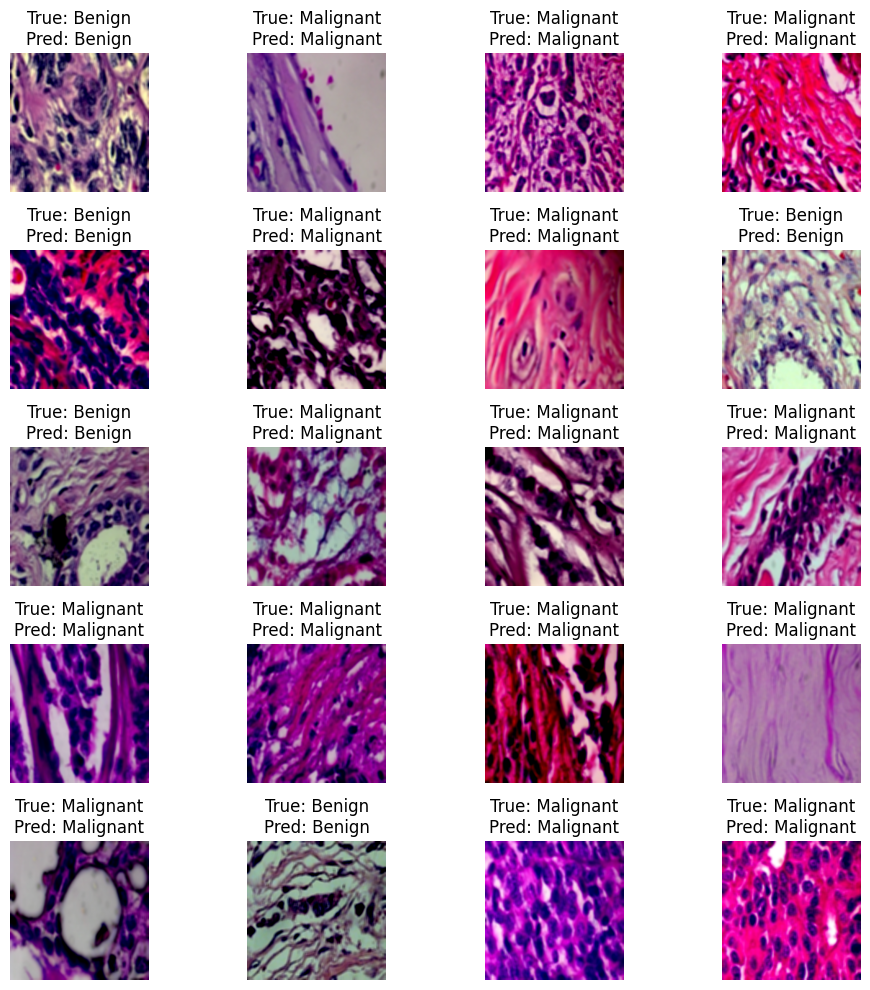

In [20]:
# Select 20 random indices from the test dataset
random_indices = random.sample(range(x_test.shape[0]), 20)

# Predict the labels for the test dataset
y_pred = model.predict(x_test)

# Define class names for labeling
class_names = ["Benign", "Malignant"]

# Create a figure for displaying images
plt.figure(figsize=(10, 10))

# Loop through the selected random indices
for i, idx in enumerate(random_indices):
    # Create a subplot for each image
    plt.subplot(5, 4, i + 1)
    plt.imshow(x_test[idx])  # Display the image
    plt.axis("off")  # Remove axis for a cleaner display
    
    # Set the title to show true and predicted labels
    plt.title("True: %s\nPred: %s" % (class_names[np.argmax(y_test[idx])], class_names[np.argmax(y_pred[idx])]))

# Adjust layout and show the figure
plt.tight_layout()
plt.show()